In [53]:
import pandas as pd
import numpy as np
from os import listdir
from collections import OrderedDict

Average frequency of top-100 tags from vacancies for each keyword-query.

In [54]:
mypath = 'tags/'
mean_val = {}

for d in listdir(mypath):
    avg = []
    for f in listdir(mypath + d):
        avg.append(pd.read_csv(mypath + d + '/' + f)['1.0'].mean())
    mean_val[d] = np.array(avg).mean()
    
dict(sorted(mean_val.items(), key=lambda item: item[1], reverse=True))

{'EPAM': 0.12282289993643573,
 'Intern': 0.09217398069918353,
 'Spark': 0.0805773030467926,
 'DevOps': 0.07504573135753329,
 'Typescript': 0.06708715615538088,
 'Golang': 0.06694442426084501,
 'php': 0.06457975638913047,
 'Frontend': 0.0581041841957835,
 'Data': 0.05644620139557391,
 'Javascript': 0.05520387180379417,
 'C%23': 0.047247201151732345,
 'Java': 0.046125413126087776,
 'SQL': 0.045321047012388475,
 'Data scientist': 0.04224532728915688,
 'C%2B%2B': 0.04051015198701911,
 'Python': 0.03914337906773641}

Average frequency of top-5 tags from vacancies for each keyword-query.

In [55]:
for d in listdir(mypath):
    avg = []
    for f in listdir(mypath + d):
        avg.append(pd.read_csv(mypath + d + '/' + f)['1.0'].iloc[:5].mean())
    mean_val[d] = np.array(avg).mean()
    
dict(sorted(mean_val.items(), key=lambda item: item[1], reverse=True))

{'Spark': 0.5576887014748453,
 'EPAM': 0.5083168253779564,
 'php': 0.49786473769349615,
 'DevOps': 0.46992496405748946,
 'Frontend': 0.4435959545192583,
 'Typescript': 0.4404043368369883,
 'Golang': 0.4319665042357148,
 'Intern': 0.43078090148650083,
 'Java': 0.3939481863887899,
 'Python': 0.3655967805728633,
 'Javascript': 0.35419047149314103,
 'Data': 0.3471269409026535,
 'C%2B%2B': 0.345581808823928,
 'C%23': 0.332661388334736,
 'Data scientist': 0.2732722795558968,
 'SQL': 0.2687003600295132}

Average frequency of top-100 tags from vacancies for each keyword-query in last date.

In [56]:
mypath = 'tags/'
ordered_dict = OrderedDict()

for d in listdir(mypath):
    avg = []
    avg.append(pd.read_csv(mypath + d + '/' + listdir(mypath + d)[-1])['1.0'].mean())
    ordered_dict[d] = np.array(avg).mean()
    
ordered_dict = dict(sorted(ordered_dict.items(), key=lambda item: item[1], reverse=True))
# ordered_dict

Extracting date from names of files.

In [57]:
import re


date_x = ['9']
for name_file in listdir(mypath + '/Python'):
    date_x.append(re.findall('[0-9]{4}-[0-9]{2}-[0-9]{2}', name_file)[0])

Average frequency of top-100 tags from vacancies for each keyword-query and date, sorted by last date.

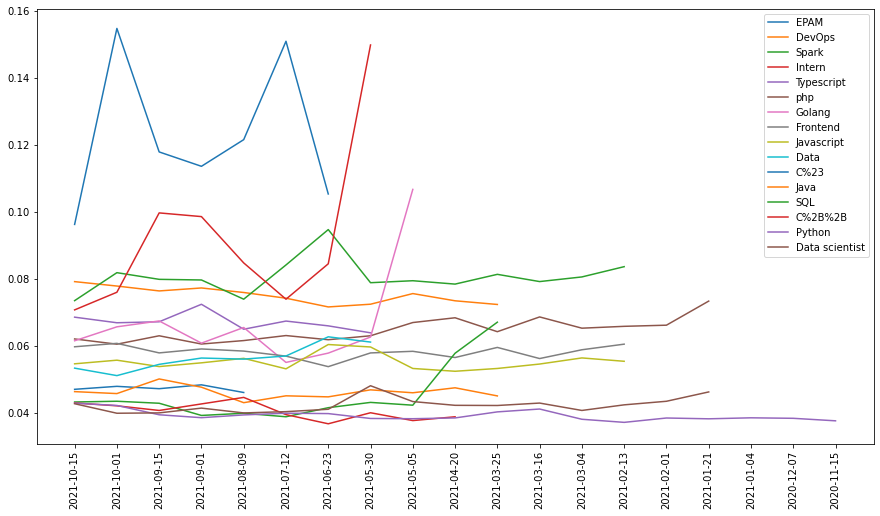

In [58]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


all_val = ordered_dict
fig, ax = plt.subplots()
fig.set_size_inches(15, 8)

for d in listdir(mypath):
    val = []
    for f in listdir(mypath + d):
        val.append(pd.read_csv(mypath + d + '/' + f)['1.0'].mean())
    all_val[d] = val[::-1]
    
all_val.keys()
[ax.plot(all_val[i]) for i in all_val.keys()]
ax.legend([i for i in all_val.keys()])
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.set_xticklabels(sorted(date_x, reverse=True), rotation=90)
plt.show()